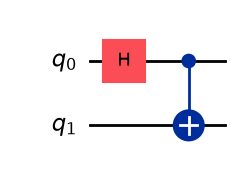

In [3]:
from qiskit import QuantumCircuit, transpile

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.draw('mpl')

{'00': 504, '11': 520}


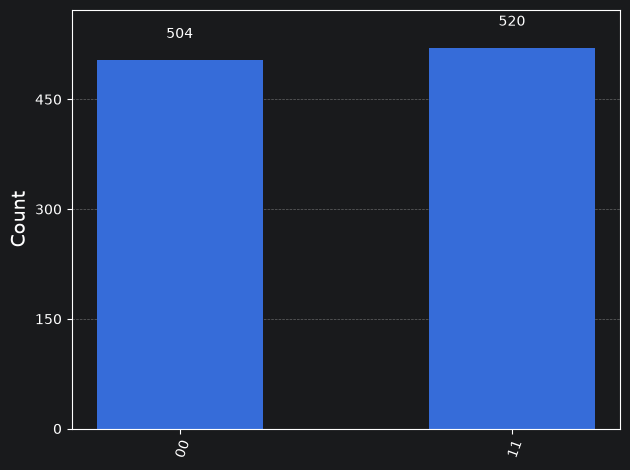

In [8]:
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data.meas.get_counts())

counts = result[0].data.meas.get_counts()
plot_histogram(counts)

In [10]:
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

state = Statevector.from_instruction(qc)

print(state)
print(state.data)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Counts:
{'00': 538, '11': 486}


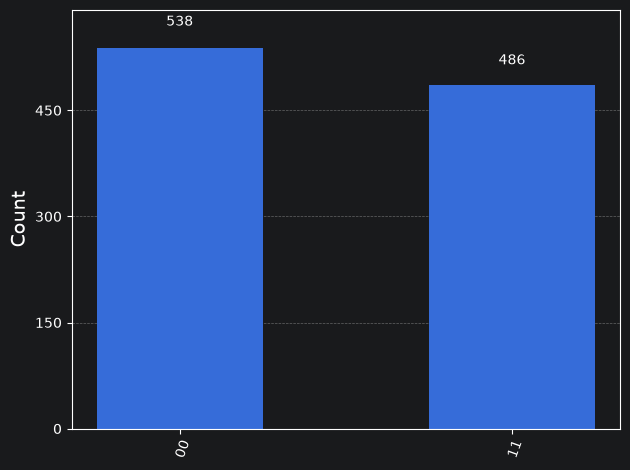

In [31]:
bell_circuit = QuantumCircuit(2)
bell_circuit.h(0)
bell_circuit.cx(0,1)

State = Statevector.from_instruction(bell_circuit)
print(State.data)
print(State)

bell_circuit.measure_all()
bell_circuit.draw('mpl')

simulator = AerSimulator()
compiled_bell_circuit = transpile(bell_circuit, simulator)

results = simulator.run(
    compiled_bell_circuit,
    shots = 1024
).result()

counts = result.get_counts()
print("\nCounts:")
print (counts)

plot_histogram(counts)